# LLM-powered Financial Fraud Detection System

# Dataset Summary — Credit Card Fraud Detection

# About the Dataset
This dataset contains **284,807 real credit card transactions** made by 
European cardholders over **2 days in September 2013**. It was collected 
and shared by the Machine Learning Group at Université Libre de Bruxelles 
(ULB) for fraud detection research.

# Goal
Build a machine learning model that can automatically detect fraudulent 
transactions in real-time — flagging suspicious activity before the bank 
loses money.

# Class Distribution
- **284,315 transactions** are legitimate (Class = 0) — 99.827%
- **492 transactions** are fraudulent (Class = 1) — 0.173%
- This is a **severely imbalanced dataset** — fraud is extremely rare

# Column Descriptions

| Column | Type | Description |
|--------|------|-------------|
| Time | Numerical | Seconds elapsed since the first transaction in the dataset |
| V1–V28 | Numerical | **PCA-transformed features** — original features were anonymized by the bank for privacy and legal compliance. Cannot be reverse-engineered. |
| Amount | Numerical | Transaction amount in Euros — this is a real, untransformed value |
| Class | Binary | **Target variable** — 0 = Legitimate, 1 = Fraud |

# Why V1–V28 Cannot Be Named
The bank applied **PCA (Principal Component Analysis)** to the original 
28 features before releasing the dataset. This was done for two reasons:

1. **Privacy law** — GDPR prohibits sharing identifiable customer data publicly
2. **Security** — exposing real feature names would help fraudsters 
   reverse-engineer the detection system

Despite anonymization, the mathematical fraud patterns are fully preserved. 
The model learns from these patterns just as effectively as it would 
from named features.

# Key Challenges
1. **Class imbalance** — 99.83% legitimate vs 0.17% fraud makes accuracy 
   a useless metric. We use F1 Score instead.
2. **No feature names** — V1–V28 are anonymous. SHAP explainability helps 
   us understand which features matter most.
3. **Real-world complexity** — Fraud patterns are subtle and overlap 
   with legitimate transactions.

# What This Dataset Represents in Production
In real banks, data scientists never see raw customer data. They always 
work with anonymized or encrypted features — exactly like V1–V28 here. 
This dataset accurately mirrors real production fraud detection workflows 
at financial institutions like JP Morgan, Goldman Sachs, and Capital One.

# Solution Approach
1. **XGBoost classifier** — best model for imbalanced tabular data
2. **SMOTE oversampling** — fix class imbalance on training data only
3. **SHAP explainability** — explain WHY each transaction was flagged
4. **LangChain RAG pipeline** — retrieve relevant FATF/FinCEN regulations 
   for each fraud flag
5. **FastAPI + Streamlit** — deploy as a production web application

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as pyplot
import seaborn as sns

df = pd.read_csv(r'c:\users\imnaz\fraud-detection-llm\data\raw\creditcard.csv')
print(f"Dataset Loaded Successfully")
print(f"Shape: {df.shape}")
df.head()




Dataset Loaded Successfully
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
print(f"Total Columns: {df.shape[1]}")
print(f"ALL THE COLUMNS ARE ")
print(df.columns.tolist())
print(df.columns)


Total Columns: 31
ALL THE COLUMNS ARE 
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [7]:
print(df[['Time', 'Amount', 'Class']].describe())

                Time         Amount          Class
count  284807.000000  284807.000000  284807.000000
mean    94813.859575      88.349619       0.001727
std     47488.145955     250.120109       0.041527
min         0.000000       0.000000       0.000000
25%     54201.500000       5.600000       0.000000
50%     84692.000000      22.000000       0.000000
75%    139320.500000      77.165000       0.000000
max    172792.000000   25691.160000       1.000000


In [8]:

print(df['Class'].count())
print(f"\nFraude: {df['Class'].sum()} Fraud Transactions")
print(f"Legitimate: {(df['Class']==0).sum()} Legitimate Transactions")
print(f"Fraud rate: {df['Class'].mean()*100:.3f}%")

len(df['Class'].unique())

284807

Fraude: 492 Fraud Transactions
Legitimate: 284315 Legitimate Transactions
Fraud rate: 0.173%


2

In [9]:
import os

# Create folders if they don't exist

os.makedirs('../assets', exist_ok=True)
os.makedirs('../data/raw', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)

print("All folders created!")
fraud = df['Class'].sum()
legitimate = (df['Class']==0).sum()
total = len(df)

fraud_pct = fraud/total*100
legit_pct = legitimate/total*100

# Text visual bar
bar_length = 40
fraud_bar = int(fraud_pct * bar_length / 100)
legit_bar = int(legit_pct * bar_length / 100)

print("Class Distribution")
print("="*50)
print(f"Legitimate  {'█' * legit_bar}  {legit_pct:.2f}%  ({legitimate:,})")
print(f"Fraud       {'█' * fraud_bar}{'░' * (bar_length - fraud_bar)}  {fraud_pct:.3f}%  ({fraud:,})")
print("="*50)
print(f"Total: {total:,} transactions")

All folders created!
Class Distribution
Legitimate  ███████████████████████████████████████  99.83%  (284,315)
Fraud       ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  0.173%  (492)
Total: 284,807 transactions


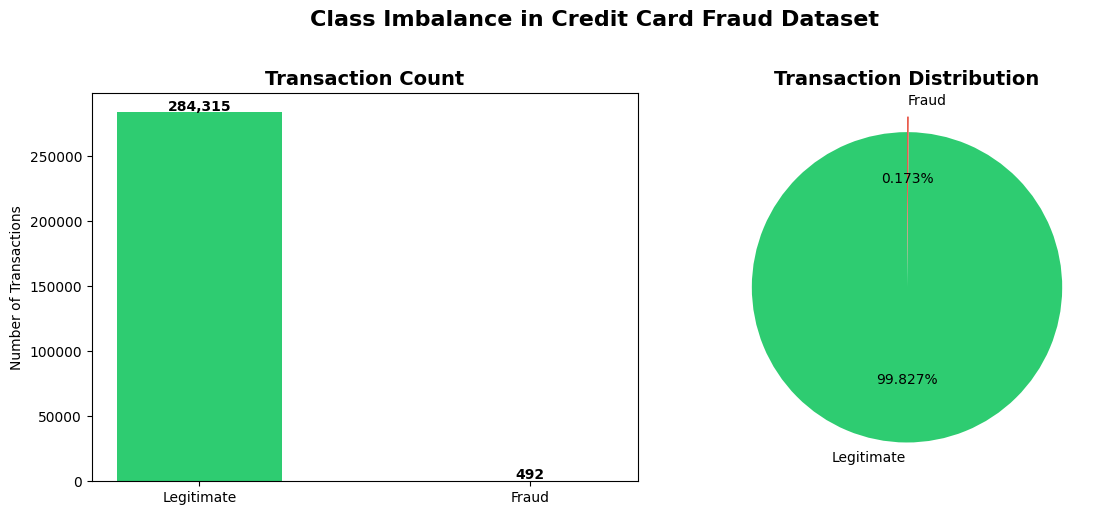


Chart saved to assets folder!


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1 — Bar chart
colors = ['#2ecc71', '#e74c3c']
counts = [legitimate, fraud]
labels = ['Legitimate', 'Fraud']

axes[0].bar(labels, counts, color=colors, width=0.5)
axes[0].set_title('Transaction Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for i, count in enumerate(counts):
    axes[0].text(i, count + 1000, f'{count:,}', 
                 ha='center', fontweight='bold')

# Chart 2 — Pie chart
axes[1].pie(counts, labels=labels, colors=colors, 
            autopct='%1.3f%%', startangle=90,
            explode=(0, 0.1))
axes[1].set_title('Transaction Distribution', 
                   fontsize=14, fontweight='bold')

plt.suptitle('Class Imbalance in Credit Card Fraud Dataset', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/class_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nChart saved to assets folder!")

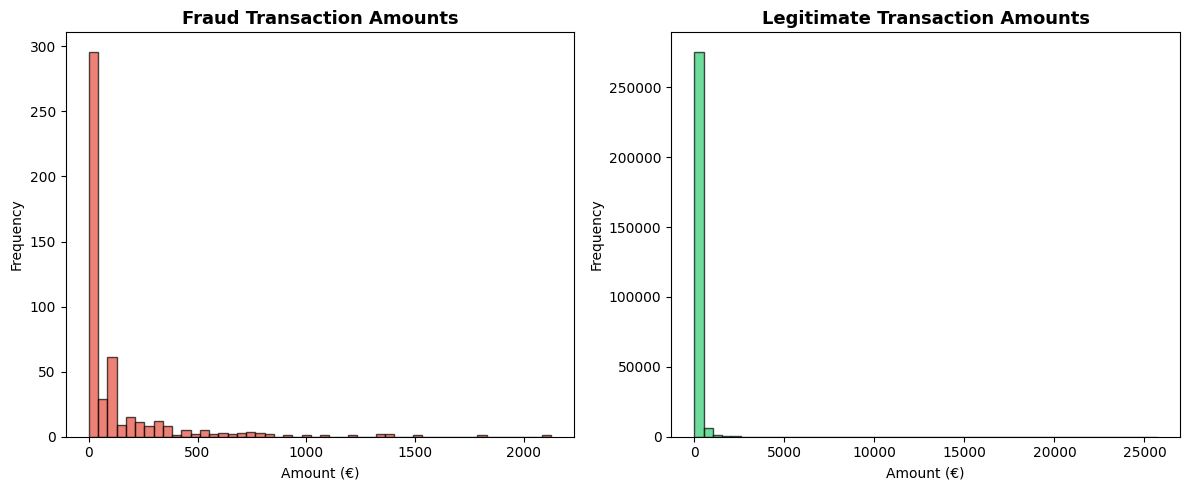


Fraud avg amount:      €122.21
Legitimate avg amount: €88.29
Max fraud amount:      €2125.87


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fraud_amounts = df[df['Class']==1]['Amount']
legit_amounts = df[df['Class']==0]['Amount']

# Fraud amounts
axes[0].hist(fraud_amounts, bins=50, 
             color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0].set_title('Fraud Transaction Amounts', 
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Amount (€)')
axes[0].set_ylabel('Frequency')

# Legitimate amounts  
axes[1].hist(legit_amounts, bins=50, 
             color='#2ecc71', alpha=0.7, edgecolor='black')
axes[1].set_title('Legitimate Transaction Amounts', 
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Amount (€)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../assets/amount_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFraud avg amount:      €{fraud_amounts.mean():.2f}")
print(f"Legitimate avg amount: €{legit_amounts.mean():.2f}")
print(f"Max fraud amount:      €{fraud_amounts.max():.2f}")

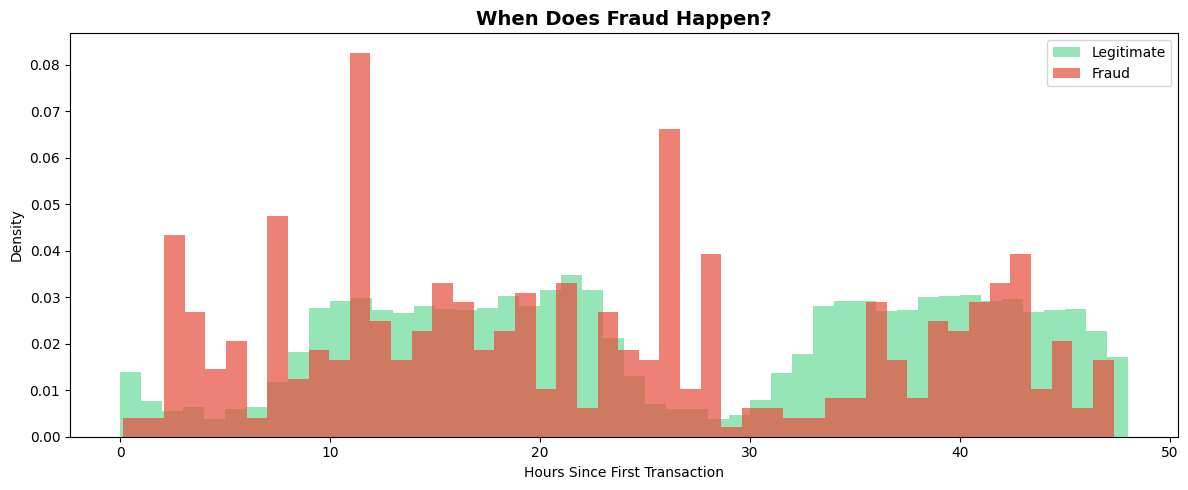

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

fraud_time = df[df['Class']==1]['Time']/3600
legit_time = df[df['Class']==0]['Time']/3600

ax.hist(legit_time, bins=48, alpha=0.5, 
        color='#2ecc71', label='Legitimate', density=True)
ax.hist(fraud_time, bins=48, alpha=0.7, 
        color='#e74c3c', label='Fraud', density=True)

ax.set_xlabel('Hours Since First Transaction')
ax.set_ylabel('Density')
ax.set_title('When Does Fraud Happen?', 
              fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('../assets/time_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.show()